# Bout frequency mixed-effects analysis

This notebook focuses only on **all-bout frequency** and tests stimulus-evoked changes using **mixed-effects models**.

It includes:

1. **Per-stimulus analysis** for the 7 key stimuli  
2. **Valence analysis** combining appetitive vs aversive stimuli  
3. **Fish-level paired plots** with numeric p-values  
4. Saving output tables to CSV

## Expected input
This notebook assumes you already have a dataframe called `stimulus_df` in memory with at least:

- `fish_id`
- `stimulus`
- `trial_number`
- `bout_indx`

Optional but helpful:
- `fish_id_clean`
- `session` (or `fish_id` containing `_fb` / `_hb`)

If `all_bout_freq_prestim` / `all_bout_freq_poststim` are not present, they will be computed automatically.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from pathlib import Path
from ast import literal_eval
plt.rcParams["figure.dpi"] = 120

## Configuration

In [2]:
# --- key stimuli ---
# key_stimuli = ('ade', 'cad_2.5mm', 'ph4.5', 'qui_2.5mm', 'fex1', 'kw', 'pro_2.5mm')
# key_stimuli = ('cad_250um', 'qui_250um', 'fex2', 'pro_250um')
key_stimuli = ('cad_25um', 'qui_25um', 'fex3', 'pro_25um')


# positive_stims = ["fex1", "kw", "pro_2.5mm"]
# negative_stims = ["ade", "cad_2.5mm", "ph4.5", "qui_2.5mm"]

# positive_stims = ["fex2","pro_250um"]
# negative_stims = ["cad_250um", "qui_250um"]

positive_stims = ["fex3","pro_25um"]
negative_stims = ["cad_25um", "qui_25um"]

# --- Stimulus Labels & Colors for plotting ---
# stimulus_labels = {
#     "ade": "Ade", "cad_2.5mm": "Cad", "fex1": "Fex",
#     "kw": "Kin", "ph4.5": "HCl", "pro_2.5mm": "Pro", "qui_2.5mm": "Qun"
# }

# stimulus_labels = {
#     "cad_250um": "Cad Int.", "fex2": "Fex Int.", "pro_250um": "Pro Int.", "qui_250um": "Qun Int."
# }

stimulus_labels = {
    "cad_25um": "Cad Low", "fex3": "Fex Low", "pro_25um": "Pro Low", "qui_25um": "Qun Low"
}

# stimulus_order = ["ade",  "cad_2.5mm", "ph4.5", "qui_2.5mm", "fex1", "kw", "pro_2.5mm"]
# stimulus_order = ['cad_250um', 'qui_250um', 'fex2', 'pro_250um']
stimulus_order = ['cad_25um', 'qui_25um', 'fex3', 'pro_25um']

# stimulus_colors = {
#     "Ade": "plum", "Cad": "mediumorchid", "Fex": "limegreen",
#     "Kin": "forestgreen", "HCl": "fuchsia", "Pro": "olive", "Qun": "deeppink"
# }

# stimulus_colors = {
#     "Cad Int.": "violet", "Fex Int.": "seagreen",
#     "Pro Int.": "olivedrab", "Qun Int.": "palevioletred"
# }


stimulus_colors = {
    "Cad Low": "plum", "Fex Low": "springgreen",
    "Pro Low": "yellowgreen", "Qun Low": "pink"
}

valence_labels = {"POS": "Appetitive Low", "NEG": "Aversive Low"}
valence_colors = {"POS": "limegreen", "NEG": "deeppink"}

# --- bout frequency window settings ---
sampling_freq = 60.85
stimulus_onset_frame = 3225
window_sec = 20
window_frames = int(window_sec * sampling_freq)

# --- output folder ---
output_dir = Path.cwd() / "bout_frequency_mixed_model_outputs"
output_dir.mkdir(exist_ok=True)
output_dir

PosixPath('/Users/bethanjenkins/Documents/valence_paper_code/Sense/bout_frequency_mixed_model_outputs')

In [3]:
def load_behavior_data(path, suffix):
    df = pd.read_csv(path)
    
    # standardize fish_id
    df['fish_id'] = df['fish_id'].astype(str) + suffix
    
    # safely parse stringified lists
    df['angles'] = df['angles'].apply(literal_eval)
    df['bout_indx'] = df['bouts'].apply(literal_eval)
    
    return df

In [4]:
bhv_fb = load_behavior_data(
    '/Volumes/LaCie/larval_HuC/behavior/7dpf_fb_behavior_traces_posture.csv',
    '_fb'
)

bhv_hb = load_behavior_data(
    '/Volumes/LaCie/larval_HuC/behavior/7dpf_hb_behavior_traces_posture.csv',
    '_hb'
)

bhv = pd.concat([bhv_fb, bhv_hb], ignore_index=True)

stimulus_df = bhv[bhv['stimulus'].isin(key_stimuli)]

## Prepare identifiers

In [5]:
# Work on a copy
stimulus_df = stimulus_df.copy()

# Standardize fish_id across sessions if needed
if "fish_id_clean" not in stimulus_df.columns:
    stimulus_df["fish_id_clean"] = (
        stimulus_df["fish_id"]
        .astype(str)
        .str.replace(r"(_fb|_hb)$", "", regex=True)
    )

# Add session if missing
if "session" not in stimulus_df.columns:
    stimulus_df["session"] = (
        stimulus_df["fish_id"]
        .astype(str)
        .str.extract(r"(fb|hb)", expand=False)
    )

print("n rows:", len(stimulus_df))
print("n fish:", stimulus_df["fish_id_clean"].nunique())
print("session values:", stimulus_df["session"].dropna().unique())
print("stimuli present:", sorted(stimulus_df["stimulus"].dropna().unique()))

n rows: 240
n fish: 10
session values: ['fb' 'hb']
stimuli present: ['cad_25um', 'fex3', 'pro_25um', 'qui_25um']


## Compute all-bout frequency if needed

In [6]:
def calculate_all_bout_frequency(
    bouts,
    stimulus_onset_frame,
    window_frames,
    sampling_freq,
):
    pre_stim_bouts = [
        b for b in bouts
        if stimulus_onset_frame - window_frames <= b[0] < stimulus_onset_frame
    ]
    post_stim_bouts = [
        b for b in bouts
        if stimulus_onset_frame <= b[0] < stimulus_onset_frame + window_frames
    ]

    duration_s = window_frames / sampling_freq
    pre_freq = len(pre_stim_bouts) / duration_s if duration_s > 0 else np.nan
    post_freq = len(post_stim_bouts) / duration_s if duration_s > 0 else np.nan

    return pre_freq, post_freq


if not {"all_bout_freq_prestim", "all_bout_freq_poststim"}.issubset(stimulus_df.columns):
    pre_vals = []
    post_vals = []

    for _, row in stimulus_df.iterrows():
        pre_freq, post_freq = calculate_all_bout_frequency(
            bouts=row["bout_indx"],
            stimulus_onset_frame=stimulus_onset_frame,
            window_frames=window_frames,
            sampling_freq=sampling_freq,
        )
        pre_vals.append(pre_freq)
        post_vals.append(post_freq)

    stimulus_df["all_bout_freq_prestim"] = pre_vals
    stimulus_df["all_bout_freq_poststim"] = post_vals

# Convert once to bouts/min for easier interpretation

stimulus_df[[
    "stimulus",
    "trial_number",
    "all_bout_freq_prestim",
    "all_bout_freq_poststim"
]].head()

,stimulus,trial_number,all_bout_freq_prestim,all_bout_freq_poststim
9,cad_25um,1,0.15,0.25
10,cad_25um,2,0.30,0.10
11,cad_25um,3,0.20,0.20
18,fex3,1,0.40,0.25
19,fex3,2,0.00,0.00


## Long-format dataframe

In [7]:
df_long = stimulus_df.melt(
    id_vars=["fish_id_clean", "session", "stimulus", "trial_number"],
    value_vars=["all_bout_freq_prestim", "all_bout_freq_poststim"],
    var_name="condition",
    value_name="bout_frequency"
)

df_long["condition"] = df_long["condition"].replace({
    "all_bout_freq_prestim": "Prestim",
    "all_bout_freq_poststim": "Poststim",
})

# Set the reference level explicitly
df_long["condition"] = pd.Categorical(
    df_long["condition"],
    categories=["Prestim", "Poststim"],
    ordered=True
)

# Keep only key stimuli
df_long = df_long[df_long["stimulus"].isin(key_stimuli)].copy()

df_long.head()

,fish_id_clean,session,stimulus,trial_number,condition,bout_frequency
0,230713,fb,cad_25um,1,Prestim,0.15
1,230713,fb,cad_25um,2,Prestim,0.30
2,230713,fb,cad_25um,3,Prestim,0.20
3,230713,fb,fex3,1,Prestim,0.40
4,230713,fb,fex3,2,Prestim,0.00


## Helper functions

In [117]:
def run_mixed_models(df, group_col):
    results = []

    for group_name in sorted(df[group_col].dropna().unique()):
        g = df[df[group_col] == group_name].copy()

        if g.empty:
            continue

        # session random effect only if available / non-null
        use_session = "session" in g.columns and g["session"].notna().any()

        if use_session:
            model = smf.mixedlm(
                "bout_frequency ~ condition",
                g,
                groups=g["fish_id_clean"],
                vc_formula={"session": "0 + C(session)"}
            )
        else:
            model = smf.mixedlm(
                "bout_frequency ~ condition",
                g,
                groups=g["fish_id_clean"]
            )

        fit = model.fit()

        # extract p-value robustly
        pvals = fit.pvalues
        if "condition[T.Poststim]" in pvals:
            p_value = pvals["condition[T.Poststim]"]
        elif "condition[T.Prestim]" in pvals:
            p_value = pvals["condition[T.Prestim]"]
        else:
            p_value = np.nan

        results.append({
            group_col: group_name,
            "n_fish": g["fish_id_clean"].nunique(),
            "p_value": p_value,
        })

    return pd.DataFrame(results)


def plot_paired_fish_by_group(
    fish_plot_df,
    results_df,
    group_col,
    group_order,
    group_title_map,
    group_color_map,
    ylabel="Bout Frequency (bouts/s)",
    figsize=(18, 5),
):
    fig, axes = plt.subplots(1, len(group_order), figsize=figsize, sharey=True)

    if len(group_order) == 1:
        axes = [axes]

    for i, group_name in enumerate(group_order):
        ax = axes[i]

        g = fish_plot_df[fish_plot_df[group_col] == group_name].copy()

        paired = g.pivot_table(
            index="fish_id_clean",
            columns="condition",
            values="bout_frequency",
            aggfunc="mean"
        ).dropna()

        if paired.empty:
            ax.set_title(group_title_map.get(group_name, group_name))
            continue

        # paired lines
        for _, row in paired.iterrows():
            ax.plot(
                [0, 1],
                [row["Prestim"], row["Poststim"]],
                color="0.7",
                linewidth=1.2,
                alpha=0.8,
                zorder=1
            )

        # fish points
        ax.scatter(
            np.zeros(len(paired)),
            paired["Prestim"],
            color="black",
            s=35,
            zorder=2
        )
        ax.scatter(
            np.ones(len(paired)),
            paired["Poststim"],
            color=group_color_map.get(group_name, "gray"),
            s=35,
            zorder=2
        )

        # mean bars
        pre_mean = paired["Prestim"].mean()
        post_mean = paired["Poststim"].mean()

        ax.hlines(pre_mean, -0.12, 0.12, color="black", linewidth=2.5, zorder=3)
        ax.hlines(post_mean, 0.88, 1.12, color="black", linewidth=2.5, zorder=3)

        # p-value
        p_row = results_df[results_df[group_col] == group_name]
        if not p_row.empty:
            p = p_row.iloc[0]["p_value"]
            y = 0.8
            ax.text(
                0.5,
                y,
                f"p = {p:.3f}",
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold"
            )

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Pre", "Post"], fontsize=12)
        ax.set_title(group_title_map.get(group_name, group_name), fontsize=18)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", width=1.5, length=4, direction="out", labelsize=20)

    axes[0].set_ylabel(ylabel, fontsize=20)
    plt.tight_layout()
    plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_all_bout_Low_concs_freq_mixed_effect_model.svg", format="svg", dpi=300, bbox_inches="tight")
    return fig, axes

## 1) Per-stimulus mixed-effects analysis

In [118]:
mixed_results_stimulus = run_mixed_models(df_long, group_col="stimulus")
mixed_results_stimulus["stimulus_label"] = mixed_results_stimulus["stimulus"].replace(stimulus_labels)
mixed_results_stimulus

,stimulus,n_fish,p_value,stimulus_label
0,cad_25um,10,0.466548,Cad Low
1,fex3,10,0.738439,Fex Low
2,pro_25um,10,0.946876,Pro Low
3,qui_25um,10,0.595674,Qun Low


/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_1910/2252919209.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_long.groupby(["fish_id_clean", "stimulus", "condition"], as_index=False)["bout_frequency"]
/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_1910/357654018.py:67: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  paired = g.pivot_table(
/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_1910/357654018.py:67: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the 

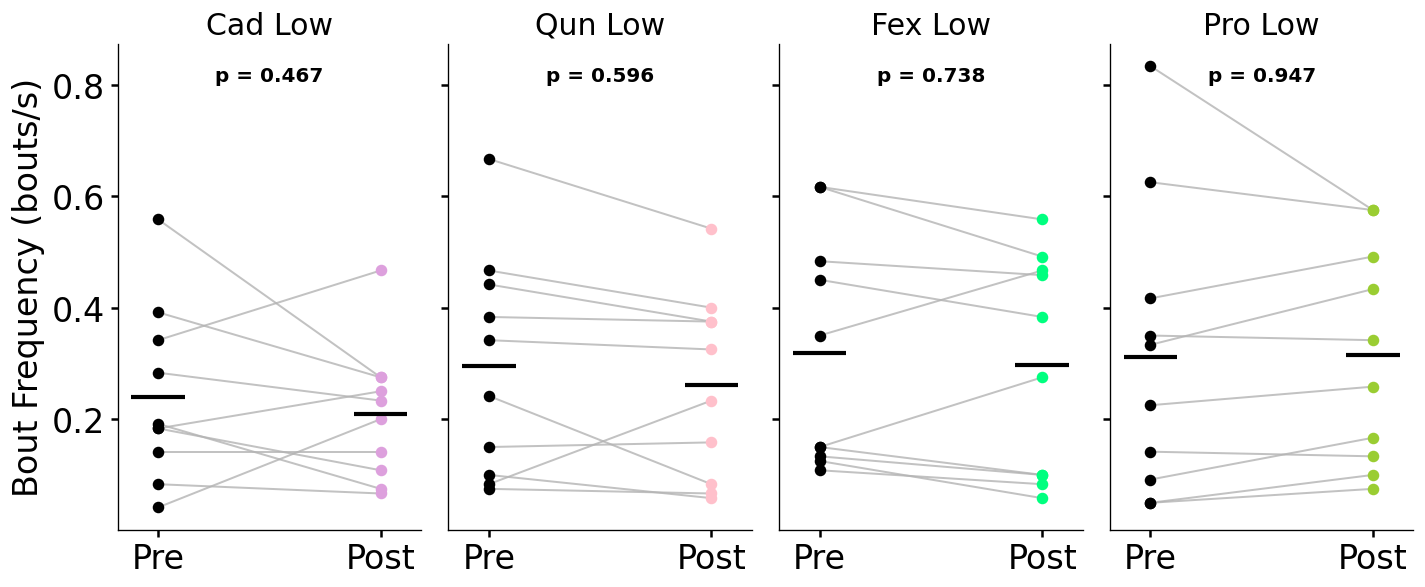

In [119]:
fish_plot_df_stimulus = (
    df_long.groupby(["fish_id_clean", "stimulus", "condition"], as_index=False)["bout_frequency"]
    .mean()
)


fig, axes = plot_paired_fish_by_group(
    fish_plot_df=fish_plot_df_stimulus,
    results_df=mixed_results_stimulus,
    group_col="stimulus",
    group_order=stimulus_order,
    group_title_map=stimulus_labels,
    group_color_map={k: stimulus_colors[v] for k, v in stimulus_labels.items()},
    ylabel="Bout Frequency (bouts/s)",
    figsize=(12, 5),
)

plt.show()

In [115]:
fish_plot_df_stimulus = (
    df_long.groupby(
        ["fish_id_clean", "stimulus", "condition"],
        observed=False
    )["bout_frequency"]
    .agg(
        fish_mean="mean",
        fish_std="std",
        n_observations="count"
    )
    .reset_index()
)

## 2) Valence-combined mixed-effects analysis

In [110]:
def stimulus_to_valence(stim):
    if stim in positive_stims:
        return "POS"
    elif stim in negative_stims:
        return "NEG"
    return np.nan

df_long_valence = df_long.copy()
df_long_valence["valence"] = df_long_valence["stimulus"].apply(stimulus_to_valence)
df_long_valence = df_long_valence.dropna(subset=["valence"]).copy()

mixed_results_valence = run_mixed_models(df_long_valence, group_col="valence")
mixed_results_valence

,valence,n_fish,p_value
0,NEG,10,0.400858
1,POS,10,0.825672


/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_1910/216456407.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_long_valence.groupby(["fish_id_clean", "valence", "condition"], as_index=False)["bout_frequency"]
/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_1910/357654018.py:67: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  paired = g.pivot_table(
/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_1910/357654018.py:67: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retai

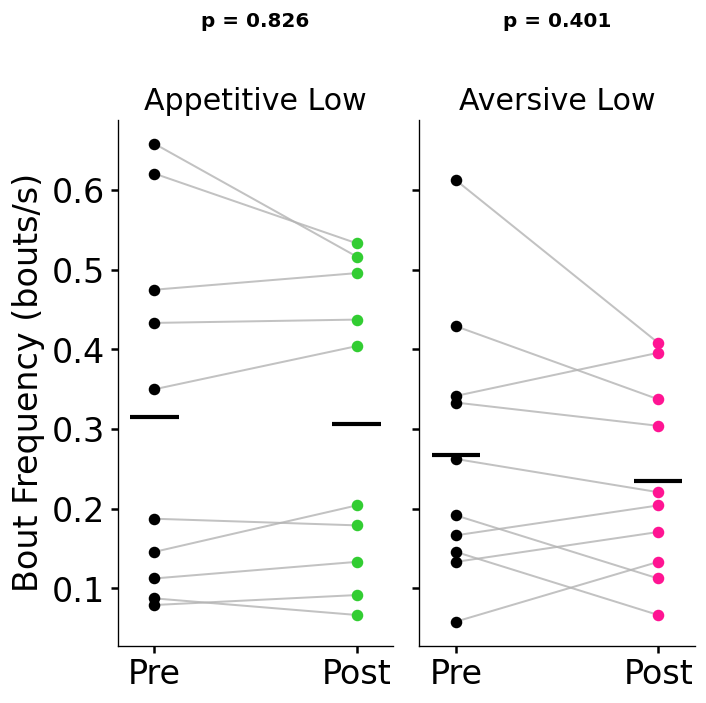

In [113]:
fish_plot_df_valence = (
    df_long_valence.groupby(["fish_id_clean", "valence", "condition"], as_index=False)["bout_frequency"]
    .mean()
)

fig, axes = plot_paired_fish_by_group(
    fish_plot_df=fish_plot_df_valence,
    results_df=mixed_results_valence,
    group_col="valence",
    group_order=["POS", "NEG"],
    group_title_map=valence_labels,
    group_color_map=valence_colors,
    ylabel="Bout Frequency (bouts/s)",
    figsize=(6, 6),
)

plt.show()

In [114]:
fish_plot_df_valence = (
    df_long_valence.groupby(
        ["fish_id_clean", "valence", "condition"],
        observed=False
    )["bout_frequency"]
    .agg(
        fish_mean="mean",
        fish_std="std",
        n_observations="count"
    )
    .reset_index()
)

## Save outputs

In [116]:
# Save per-stimulus and valence mixed-model results
mixed_results_stimulus.to_csv(output_dir / "all_bout_frequency_Low_concs_mixed_model_per_stimulus.csv", index=False)
mixed_results_valence.to_csv(output_dir / "all_bout_frequency_Low_concs_mixed_model_valence.csv", index=False)

# Save fish-level values used for plotting
fish_plot_df_stimulus.to_csv(output_dir / "all_bout_frequency_Low_concs_fish_plot_values_per_stimulus.csv", index=False)
fish_plot_df_valence.to_csv(output_dir / "all_bout_frequency_Low_concs_fish_plot_values_valence.csv", index=False)

print("Saved files to:", output_dir.resolve())

Saved files to: /Users/bethanjenkins/Documents/valence_paper_code/Sense/bout_frequency_mixed_model_outputs
